In [ ]:
# # enable for kaggle notebook server
# !pip install contractions

In [40]:
import os, gdown, gc, random, warnings
from colorama import Fore
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string, spacy
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import TweetTokenizer, word_tokenize, sent_tokenize
from nltk.stem import WordNetLemmatizer, PorterStemmer, LancasterStemmer, SnowballStemmer
import contractions
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay
from sklearn.metrics.pairwise import cosine_similarity

from pprint import pprint
from IPython.utils import io
from IPython.display import display, HTML
from tqdm.notebook import tqdm
from gensim.models import Word2Vec
from sklearn.decomposition import PCA

from langdetect import detect, DetectorFactory
from spacy.lang.en.stop_words import STOP_WORDS
from spacy.lang.en import English

nltk.download('stopwords')
nltk.download('wordnet')
nltk.download("punkt")
nltk.download('omw-1.4')
nltk.download('punkt_tab')

warnings.filterwarnings('ignore')
tqdm.pandas()

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\saivarshith\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\saivarshith\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\saivarshith\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\saivarshith\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\saivarshith\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [3]:
# DataSet main Source
# To download - https://www.kaggle.com/allen-institute-for-ai/CORD-19-research-challenge

# globals
# https://drive.google.com/uc?id=1VkNpuudQnlj7g5uUCNPJ4MKxFdDdh7bZ
DS_NAME = "metadata.csv"
BATCH_SIZE=64
dataSetDriveID = "1VkNpuudQnlj7g5uUCNPJ4MKxFdDdh7bZ"

In [4]:
# function to download the dataset from the url
def download_dataset_from_url(url, file_path):
    try:
        gdown.download(url, file_path, quiet=False)
        print(f"Successfully downloaded to {file_path}")
    except Exception as e:
        print(f"Error downloading file: {e}")

def download_and_prep_dataset(FILE_ID, downloadLoc="dataSet", dataSetName=""):
    # Download the dataset
    url = f'https://drive.google.com/uc?id={FILE_ID}'
    currentPath = os.getcwd()
    dataSetPath = os.path.abspath(os.path.join(currentPath, downloadLoc + "/"))

    # create directory if not exists
    if not os.path.exists(dataSetPath):
        os.mkdir(dataSetPath)

    fileFullPath = os.path.join(dataSetPath, dataSetName)
    print("file Path: ", fileFullPath)
    # download the dataset
    if not os.path.exists(fileFullPath):
        download_dataset_from_url(url=url, file_path=fileFullPath)

    # Load the dataset
    return fileFullPath

In [ ]:
datasetLoc = download_and_prep_dataset(FILE_ID=dataSetDriveID, dataSetName=DS_NAME)
coronaDS = pd.read_csv(datasetLoc)

columnsToKeep = ['title', 'abstract', 'authors', 'publish_time', 'journal', 'url']
coronaDS = coronaDS[columnsToKeep]
coronaDS.head(3)

file Path:  c:\Study\gitRepo\NLP\document_recommendation_search_engine\nlp_related_document_search_engine\notebook\dataSet\metadata.csv


,title,abstract,authors,publish_time,journal,url
0,Clinical features of culture-proven Mycoplasma...,OBJECTIVE: This retrospective chart review des...,"Madani, Tariq A; Al-Ghamdi, Aisha A",2001-07-04,BMC Infect Dis,https://www.ncbi.nlm.nih.gov/pmc/articles/PMC3...
1,Nitric oxide: a pro-inflammatory mediator in l...,Inflammatory diseases of the respiratory tract...,"Vliet, Albert van der; Eiserich, Jason P; Cros...",2000-08-15,Respir Res,https://www.ncbi.nlm.nih.gov/pmc/articles/PMC5...
2,Surfactant protein-D and pulmonary host defense,Surfactant protein-D (SP-D) participates in th...,"Crouch, Erika C",2000-08-25,Respir Res,https://www.ncbi.nlm.nih.gov/pmc/articles/PMC5...


### Initial Data Exploration

In [6]:
print(Fore.YELLOW)
print(coronaDS.info())
print(Fore.RESET)

print(Fore.LIGHTGREEN_EX, "As the search engine's task is to compare the query with the Journal Abstract and Title, it is safe to drop the documents/records which have missing values in these 2 columns")
print(Fore.RESET)

coronaDS.dropna(subset=['title', 'abstract'], inplace=True)
coronaDS.reset_index(drop=True, inplace=True)
coronaDS['title'] = coronaDS['title'].astype(str)
coronaDS['abstract'] = coronaDS['abstract'].astype(str)
coronaDS['authors'] = coronaDS['authors'].astype(str)
coronaDS['publish_time'] = pd.to_datetime(coronaDS['publish_time'], format='%Y-%m-%d', errors='coerce')
coronaDS['journal'] = coronaDS['journal'].astype(str)
coronaDS['url'] = coronaDS['url'].astype(str)

print(Fore.YELLOW)
print(coronaDS.info())
print(Fore.RESET)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1056660 entries, 0 to 1056659
Data columns (total 6 columns):
 #   Column        Non-Null Count    Dtype 
---  ------        --------------    ----- 
 0   title         1056157 non-null  object
 1   abstract      821116 non-null   object
 2   authors       1032791 non-null  object
 3   publish_time  1054846 non-null  object
 4   journal       969338 non-null   object
 5   url           686934 non-null   object
dtypes: object(6)
memory usage: 48.4+ MB
None

 As the search engine's task is to compare the query with the Journal Abstract and Title, it is safe to drop the documents/records which have missing values in these 2 columns


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 821005 entries, 0 to 821004
Data columns (total 6 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   title         821005 non-null  object        
 1   abstract      821005 non-null  object     

After clean-up we can see that there are no missing Values and the Dataset is clean to work with

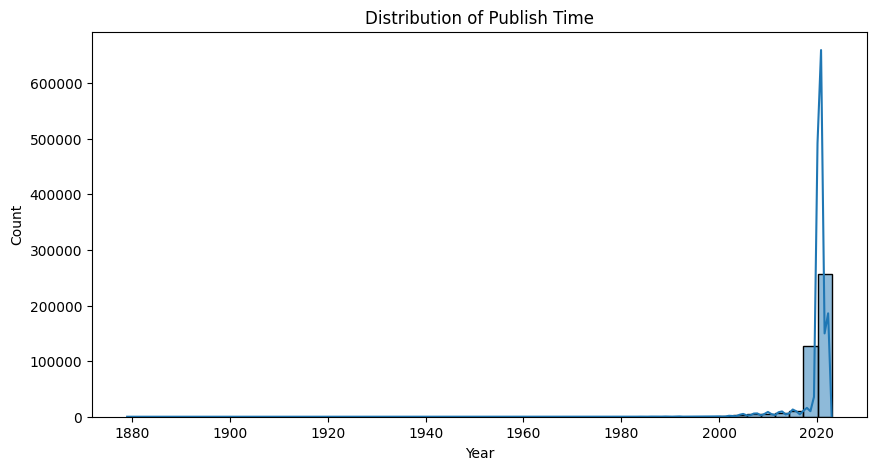

In [7]:
plt.figure(figsize=(10, 5))
sns.histplot(coronaDS['publish_time'].dt.year, bins=50, kde=True)
plt.title('Distribution of Publish Time')
plt.xlabel('Year')
plt.ylabel('Count')
plt.show()

we can see that there is a spike in the number of publications in 2020, which is expected due to the COVID-19 pandemic.

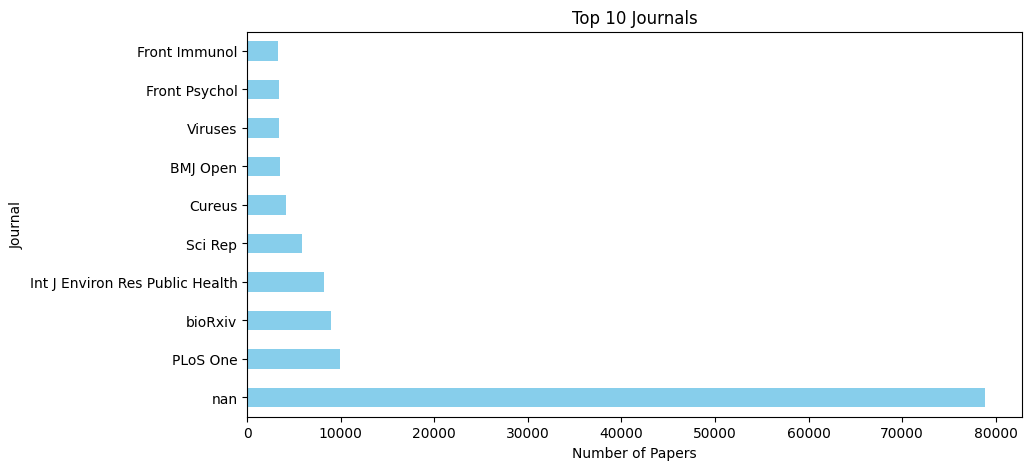

In [8]:
# Now, let's check the distribution of the number of authors per paper.
plt.figure(figsize=(10, 5))
coronaDS["journal"].value_counts().head(10).plot(kind='barh', figsize=(10, 5), color='skyblue')
plt.title('Top 10 Journals')
plt.xlabel('Number of Papers')
plt.ylabel('Journal')
plt.show()

We can see that a large proportion of the Journals are published from unknown Journals

#### Approach
- The user inputs a user query.
- We have/calculate document embedding for all the document and title Journals in the database(current DB is the database)
- We calculate the input 'query embeddings'
- We calculate the semantic simularity between query and the document enbeddings and pick the top N publications from the DataBase

#### Try out SVD based approahes

In [9]:
# create a Count Vectorizer object and pass all document abstracts to it
# count_vectorizer = CountVectorizer()
# docCountVectorizer = count_vectorizer.fit_transform(coronaDS['abstract'])

In [10]:
# print(docCountVectorizer.shape, coronaDS.shape)

#### Preparing the Data for Word2Vec

In [11]:
custom_stop_words = ['doi', 'preprint', 'copyright', 'peer', 'reviewed', 'org', 'https', 'et', 'al', 'author', 'figure',
                     'rights', 'reserved', 'permission', 'used', 'using', 'biorxiv', 'medrxiv', 'license', 'fig', 'fig.',
                     'al.', 'Elsevier', 'PMC', 'CZI', 'www']

In [322]:
def check_Languages(x):
    """
    Check the language of the text data and filter out non-English texts.
    """
    # Set the seed for reproducibility
    DetectorFactory.seed = 0

    # Detect the language of each text and filter out non-English texts
    try:
        lang = detect(x)
    except:
        lang = 'unknown'
    return lang
    

def preprocessPerWord(sentence, model):
    """
    Preprocess the text data by removing special characters, URLs, and stop words.
    """
    # Remove special characters and URLs
    sentence = re.sub(r'http\S+', '', sentence)

    # remove html tags
    sentence = re.sub(r'<.*?>', '', sentence)

    # remove special characters
    sentence = re.sub(r'[^a-zA-Z0-9\s]', '', sentence)

    # remove digits
    sentence = re.sub(r'\d+', '', sentence)

    # remove punctuation
    sentence = sentence.translate(str.maketrans('', '', string.punctuation))

    # Convert to lowercase
    sentence = sentence.lower()

    # Remove stop words
    stop_words = set(STOP_WORDS).union(set(custom_stop_words))

    # re-joining the sentences
    sentence = " ".join([str(word) for word in model(sentence) if word not in stop_words])

    return sentence

def preprocessPerSentences(sentence, model):
    iterSents = model(sentence)
    sentStripped = [word_tokenize(sent.text.strip()) for sent in iterSents.sents]
    return sentStripped


In [ ]:
# add seed as the detector is not deterministic
DetectorFactory.seed = 0
coronaDS["lang"] = coronaDS["abstract"].progress_apply(check_Languages)

  0%|          | 0/821005 [00:00<?, ?it/s]

In [323]:
# we can see that the Language count is huge. We only want to work on english documents. so dropping the rest.
print("BEFORE: Number of languages detected: ")
print(Fore.RED)
print(coronaDS["lang"].value_counts())
print(Fore.RESET)

coronaDS = coronaDS.loc[coronaDS["lang"] == "en"].reset_index(drop=True)

print("AFTER: Number of languages detected: ")
print(Fore.GREEN)
print(coronaDS["lang"].value_counts())
print(Fore.RESET)

coronaDS.drop(columns=["lang"], inplace=True)

BEFORE: Number of languages detected: 



KeyError: 'lang'

In [ ]:
## Let us use Spacy for faster tokenization
nlp = spacy.load('en_core_web_sm', disable=["tagger", "ner"])
nlp.add_pipe('sentencizer')

coronaDS["processed_abstract"] = coronaDS["abstract"].progress_apply(lambda x: preprocessPerWord(sentence=x, model=nlp))
coronaDS["listed_abstract"] = coronaDS["abstract"].progress_apply(lambda x: preprocessPerSentences(x, model=nlp))
display(coronaDS.head())


  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

,title,abstract,authors,publish_time,journal,url,processed_abstract,listed_abstract
806969,778. Prediction of Bloodstream Infection Event...,BACKGROUND: Bloodstream infection (BSI) - Cent...,"Pereira, Rogério; da Silva, Débora; Silva, Sin...",2021-12-04,Open Forum Infect Dis,https://doi.org/10.1093/ofid/ofab466.975,background bloodstream infection bsi central...,"[[BACKGROUND, :, Bloodstream, infection, (, BS..."
806970,Impact of non-pharmacological initiatives for ...,INTRODUCTION: Interventions to deal with the C...,"Chiapinotto, Sabrina; Sarria, Edgar E.; Moceli...",2021-04-26,Paediatr Respir Rev,https://www.ncbi.nlm.nih.gov/pubmed/34016531/;...,introduction interventions to deal with the co...,"[[INTRODUCTION, :], [Interventions, to, deal, ..."
806971,Bioinspired porous microspheres for sustained ...,Exosomes derived from mesenchymal stem cells (...,"Gao, Yike; Yuan, Zuoying; Yuan, Xiaojing; Wan,...",NaT,Bioact Mater,https://doi.org/10.1016/j.bioactmat.2022.01.04...,exosomes derived from mesenchymal stem cells m...,"[[Exosomes, derived, from, mesenchymal, stem, ..."
806972,“Chronic granulomatous invasive fungal rhinosi...,INTRODUCTION AND IMPORTANCE: Granulomatous chr...,"Treviño-Gonzalez, Jose Luis; Santos-Santillana...",2021-12-02,Ann Med Surg (Lond),https://doi.org/10.1016/j.amsu.2021.103129; ht...,introduction and importance granulomatous chro...,"[[INTRODUCTION, AND, IMPORTANCE, :, Granulomat..."
806973,Chinese Herbal Medicine Telehealth Outcomes fo...,Introduction: Given the seriousness of Coronav...,"Taylor-Swanson, Lisa; Taromina, Katherine; Mit...",2021-12-31,European Journal of Integrative Medicine,https://www.sciencedirect.com/science/article/...,introduction given the seriousness of coronavi...,"[[Introduction, :, Given, the, seriousness, of..."
806974,Potent neutralization of 2019 novel coronaviru...,"2019-nCoV, which is a novel coronavirus emerge...","Lei, Changhai; Fu, Wenyan; Qian, Kewen; Li, Ti...",2020-02-02,bioRxiv,https://doi.org/10.1101/2020.02.01.929976,ncov which is a novel coronavirus emerged in w...,"[[2019-nCoV, ,, which, is, a, novel, coronavir..."
806975,"Molecular-based diagnostics, including future ...",Microbiology laboratories have traditionally r...,"Goldenberg, Simon",2013-10-28,Medicine (Abingdon),https://api.elsevier.com/content/article/pii/S...,microbiology laboratories have traditionally r...,"[[Microbiology, laboratories, have, traditiona..."
806976,A Patient With Bilateral Conjunctivitis Positi...,To present a patient with bilateral conjunctiv...,"Sirakaya, Ender; Sahiner, Mustafa; Aslan Sirak...",2020-07-02,Cornea,https://www.ncbi.nlm.nih.gov/pubmed/32794685/;...,to present a patient with bilateral conjunctiv...,"[[To, present, a, patient, with, bilateral, co..."
806977,Incidental lowering of otitis-media complaints...,Given COVID-19 pandemic periodic outpatient as...,"Torretta, Sara; Capaccio, Pasquale; Coro, Ilar...",2020-07-20,Eur J Pediatr,https://doi.org/10.1007/s00431-020-03747-9; ht...,given covid pandemic periodic outpatient asses...,"[[Given, COVID-19, pandemic, periodic, outpati..."
806978,Hospital variation in admissions to neonatal i...,OBJECTIVE: To examine interhospital variation ...,"Haidari, Eman S.; Lee, Henry C.; Illuzzi, Jess...",2020-08-14,J Perinatol,https://doi.org/10.1038/s41372-020-00775-z; ht...,objective to examine interhospital variation i...,"[[OBJECTIVE, :, To, examine, interhospital, va..."


In [ ]:
word2vec_corpus = coronaDS["listed_abstract"].explode().to_list()
model = Word2Vec(sentences=word2vec_corpus,
                 min_count=1,
                 vector_size=200,
                 workers=5,
                 window=3,
                 sg=1,
                 negative=5)
model.save("Word2Vec.model")

In [ ]:
a = [0.0]*200
coronaDS["centroid"] = [a]*coronaDS.shape[0]

for index, row in coronaDS.iterrows():
    abstract = row['processed_abstract']
    words = abstract.split(" ")
    centroid = np.array([0.0]*200)
    for word in words:
        try:
            b = model.wv[word]
        except:
            continue
        centroid = np.add(centroid, b)

    coronaDS.at[index,'centroid'] = centroid.tolist()

In [ ]:
def rank_abstract(modelToUse, query, dataBase, topKMatch):
    querryEmbedding = []
    cosine_sim_list = []
    for qWord in query.split():
        try:
            querryEmbedding.append(model.wv[qWord])
        except:
            continue
    querryEmbedding = np.array(querryEmbedding)

    for idx, row in dataBase.iterrows():
        centroid = np.array(row["centroid"])
        querryEmbedding = np.array(querryEmbedding)
        cosinesim = np.sum(np.dot(querryEmbedding, np.expand_dims(centroid, axis=0).T)) / (np.linalg.norm(querryEmbedding) * np.linalg.norm(centroid))
        cosine_sim_list.append((row[["title", "abstract", "url"]], cosinesim))
    
    cosine_sim_list.sort(key=lambda x: x[1], reverse=True)
    return cosine_sim_list[:topKMatch]
    
def query(sent="", topKMatch=5):
    model = Word2Vec.load("Word2Vec.model")
    cosine_similarity_list = rank_abstract(modelToUse=model, query=sent, dataBase=coronaDS, topKMatch=5)
    for k in range(topKMatch):
        df, simScore = cosine_similarity_list[k]
        print(f"recommendation : {k}, similarity Score: {simScore}")
        print(Fore.GREEN, "\t * Title: ", df["title"])
        print(Fore.LIGHTGREEN_EX, "\t * Abstract: ", df["abstract"])
        print(Fore.BLUE, "\t * Link: ", df["url"])
        print(Fore.RESET, "-"*50)
    return cosine_similarity_list

In [419]:
query("origin of coronavirus")

recommendation : 0, similarity Score: 0.9964176291519329
 	 * Title:  A Patient With Bilateral Conjunctivitis Positive for SARS-CoV-2 RNA in a Conjunctival Sample
 	 * Abstract:  To present a patient with bilateral conjunctivitis, testing positive for viral RNA of severe acute respiratory syndrome coronavirus 2 (SARS-CoV-2) in both nasopharyngeal and conjunctival samples. METHODS: A 40-year-old man with bilateral acute conjunctivitis and suspicious signs of coronavirus disease 2019 (COVID-19) presented to the hospital. A detailed ophthalmic examination was performed. Samples obtained from conjunctival and nasopharyngeal swabs were tested by reverse transcription PCR (RT-PCR) for the detection of SARS-CoV-2 virus. Ocular findings and duration of the presence of viral RNA in the conjunctival specimens were evaluated at follow-up visits. RESULTS: Slit-lamp biomicroscopy revealed bilateral acute follicular conjunctivitis. The RT-PCR assay demonstrated the presence of viral RNA in the nasop

[(title       A Patient With Bilateral Conjunctivitis Positi...
  abstract    To present a patient with bilateral conjunctiv...
  url         https://www.ncbi.nlm.nih.gov/pubmed/32794685/;...
  Name: 806976, dtype: object,
  0.9964176291519329),
 (title       Chinese Herbal Medicine Telehealth Outcomes fo...
  abstract    Introduction: Given the seriousness of Coronav...
  url         https://www.sciencedirect.com/science/article/...
  Name: 806973, dtype: object,
  0.9899407383180642),
 (title       778. Prediction of Bloodstream Infection Event...
  abstract    BACKGROUND: Bloodstream infection (BSI) - Cent...
  url                  https://doi.org/10.1093/ofid/ofab466.975
  Name: 806969, dtype: object,
  0.9894667714862395),
 (title       Potent neutralization of 2019 novel coronaviru...
  abstract    2019-nCoV, which is a novel coronavirus emerge...
  url                 https://doi.org/10.1101/2020.02.01.929976
  Name: 806974, dtype: object,
  0.9879362317494769),
 (title       In